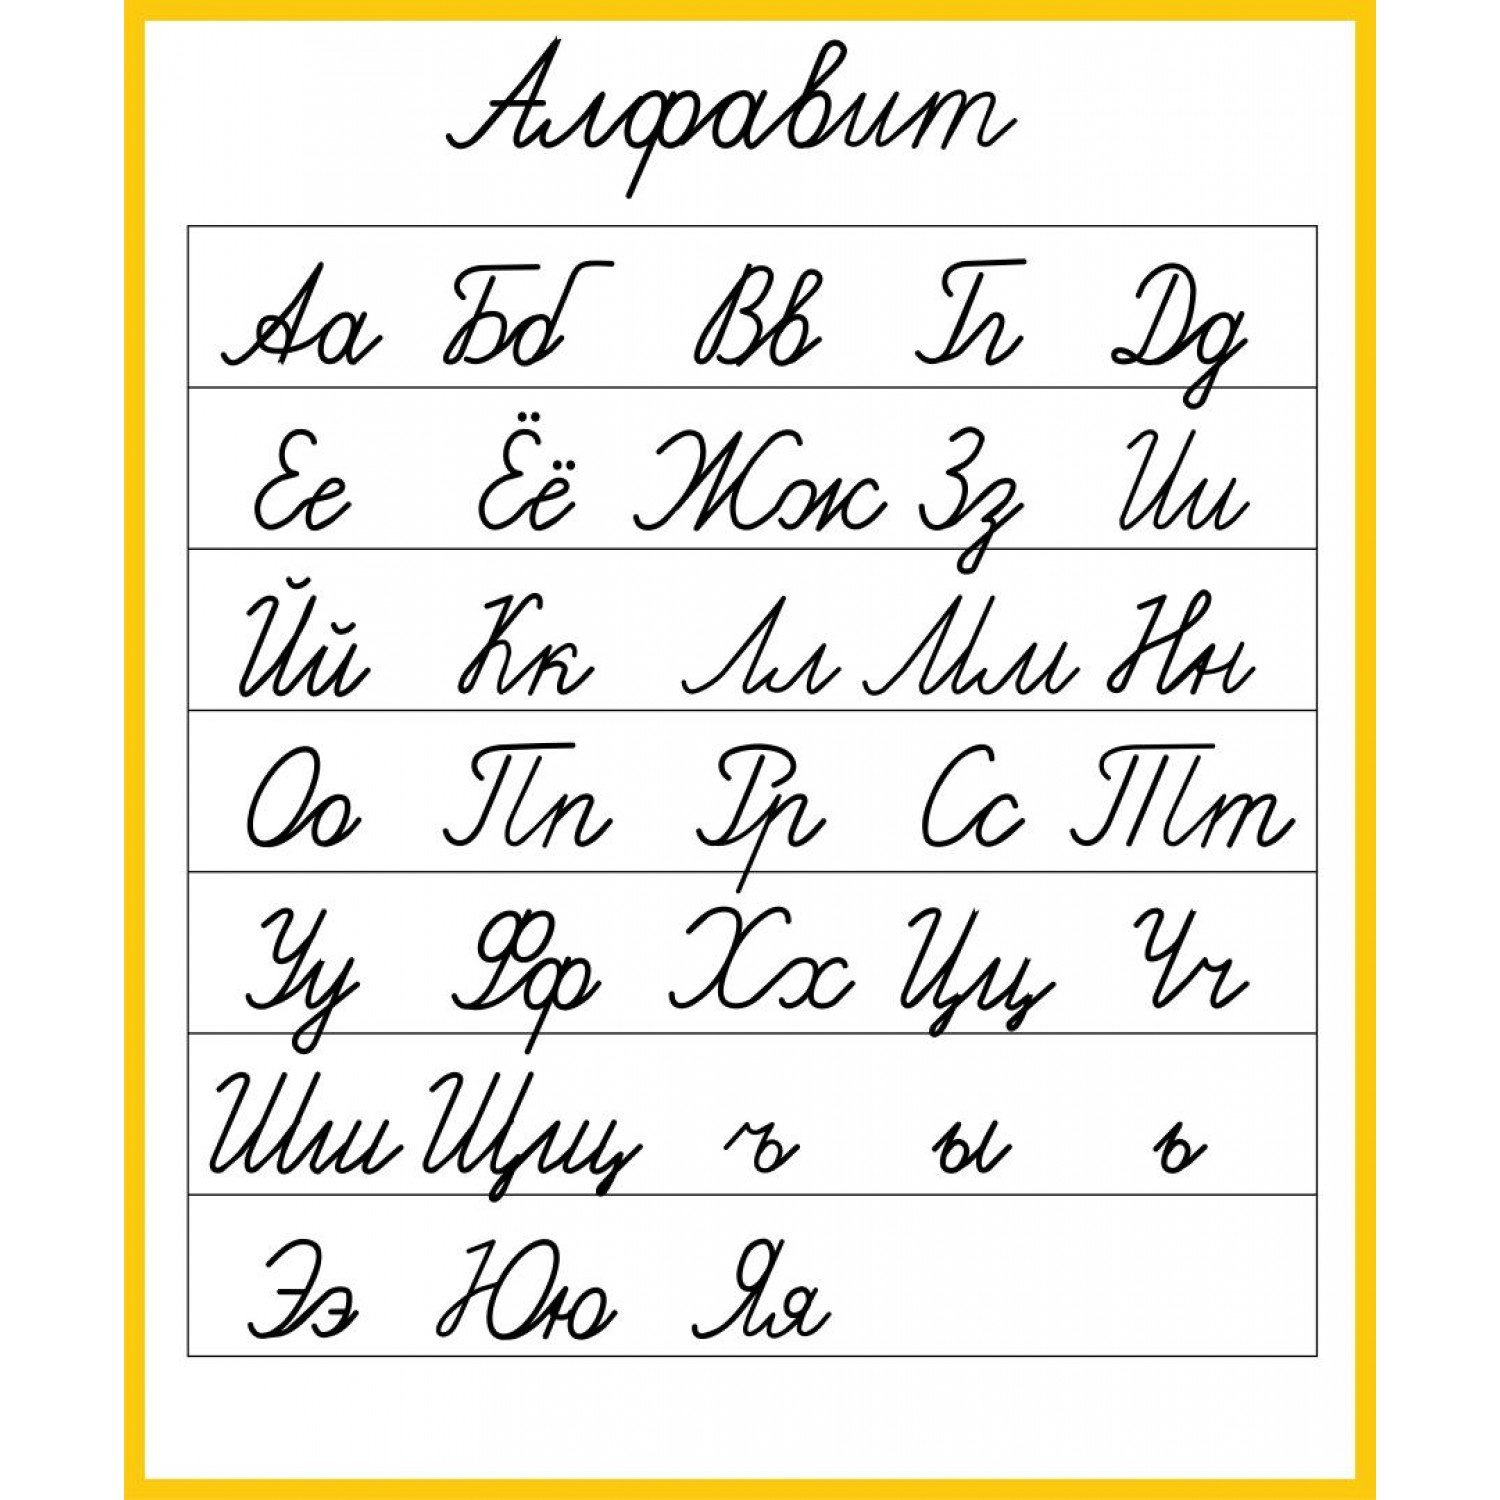

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image

display(Image(filename='alphabet_rus.jpg', width=490))


In [163]:
import importlib
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image
# Перезагрузка модуля. Надо перезагружать эту ячейку, если что-то поменяли в генераторе
importlib.reload(importlib.import_module('mnist_synthetic.lower_case_letters_generator'))
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator

generator = LowerCaseLettersGenerator(seed=42)

transform_nearest = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.NEAREST),
])

transform_bilinear = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize(28, interpolation=transforms.InterpolationMode.BILINEAR),
])

transform_bicubic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(28, interpolation=transforms.InterpolationMode.BICUBIC),
])  

In [164]:
def plot_single_image(img, label: str):
    """Отображает одно изображение без аугментаций."""
    if img.ndim == 3 and img.shape[0] == 1:
        img = img[0]  # (1, H, W) -> (H, W)
    elif img.ndim == 3 and img.shape[2] == 1:
        img = img[:, :, 0]  # (H, W, 1) -> (H, W)

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title(f'Label: {label} | Shape: {img.shape}')
    plt.axis('off')
    plt.show()

In [1]:
# Генерация изображений
# Не доделано
img = generator.generate_д()
label = 'д'
plot_single_image(img, label)

NameError: name 'generator' is not defined

In [115]:
# У меня Винда, а на ней torch не хочет делать bicubic интерполяцию без преобразования в pil
def tensor_to_pil(img):
    # img: np.ndarray (H, W) или (H, W, 1)
    if img.ndim == 3 and img.shape[2] == 1:
        img = img[:, :, 0]
    return Image.fromarray(img, mode='L')  # 'L' = grayscale

def plot_rotated_with_interpolations(img, label: str, angle: int = 30):
    pil_img = tensor_to_pil(img)

    # Все интерполяции работают с PIL
    rot_n = transforms.RandomRotation((angle, angle), interpolation=transforms.InterpolationMode.NEAREST)
    rot_b = transforms.RandomRotation((angle, angle), interpolation=transforms.InterpolationMode.BILINEAR)
    rot_c = transforms.RandomRotation((angle, angle), interpolation=transforms.InterpolationMode.BICUBIC)

    img_n = transforms.ToTensor()(rot_n(pil_img)).squeeze().numpy()
    img_b = transforms.ToTensor()(rot_b(pil_img)).squeeze().numpy()
    img_c = transforms.ToTensor()(rot_c(pil_img)).squeeze().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(img_n, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f'NEAREST ({angle}°)')
    axes[1].axis('off')

    axes[2].imshow(img_b, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title(f'BILINEAR ({angle}°)')
    axes[2].axis('off')

    axes[3].imshow(img_c, cmap='gray', vmin=0, vmax=1)
    axes[3].set_title(f'BICUBIC ({angle}°)')
    axes[3].axis('off')

    plt.suptitle(f'Label: {label}')
    plt.tight_layout()
    plt.show()

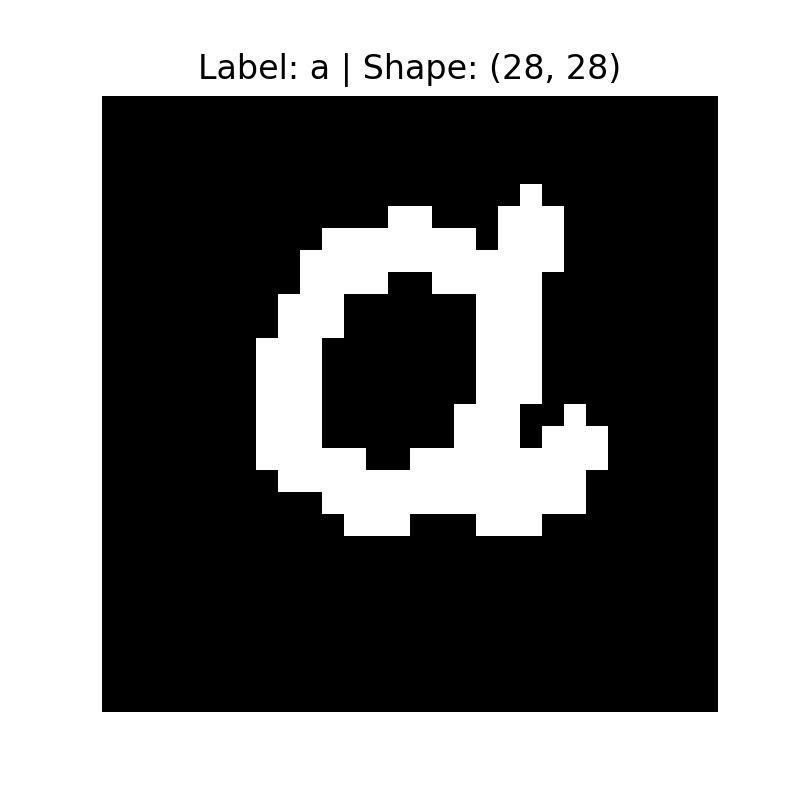

In [5]:
# Генерация изображений
img = generator.generate_а()
label = 'а'
plot_single_image(img, label)

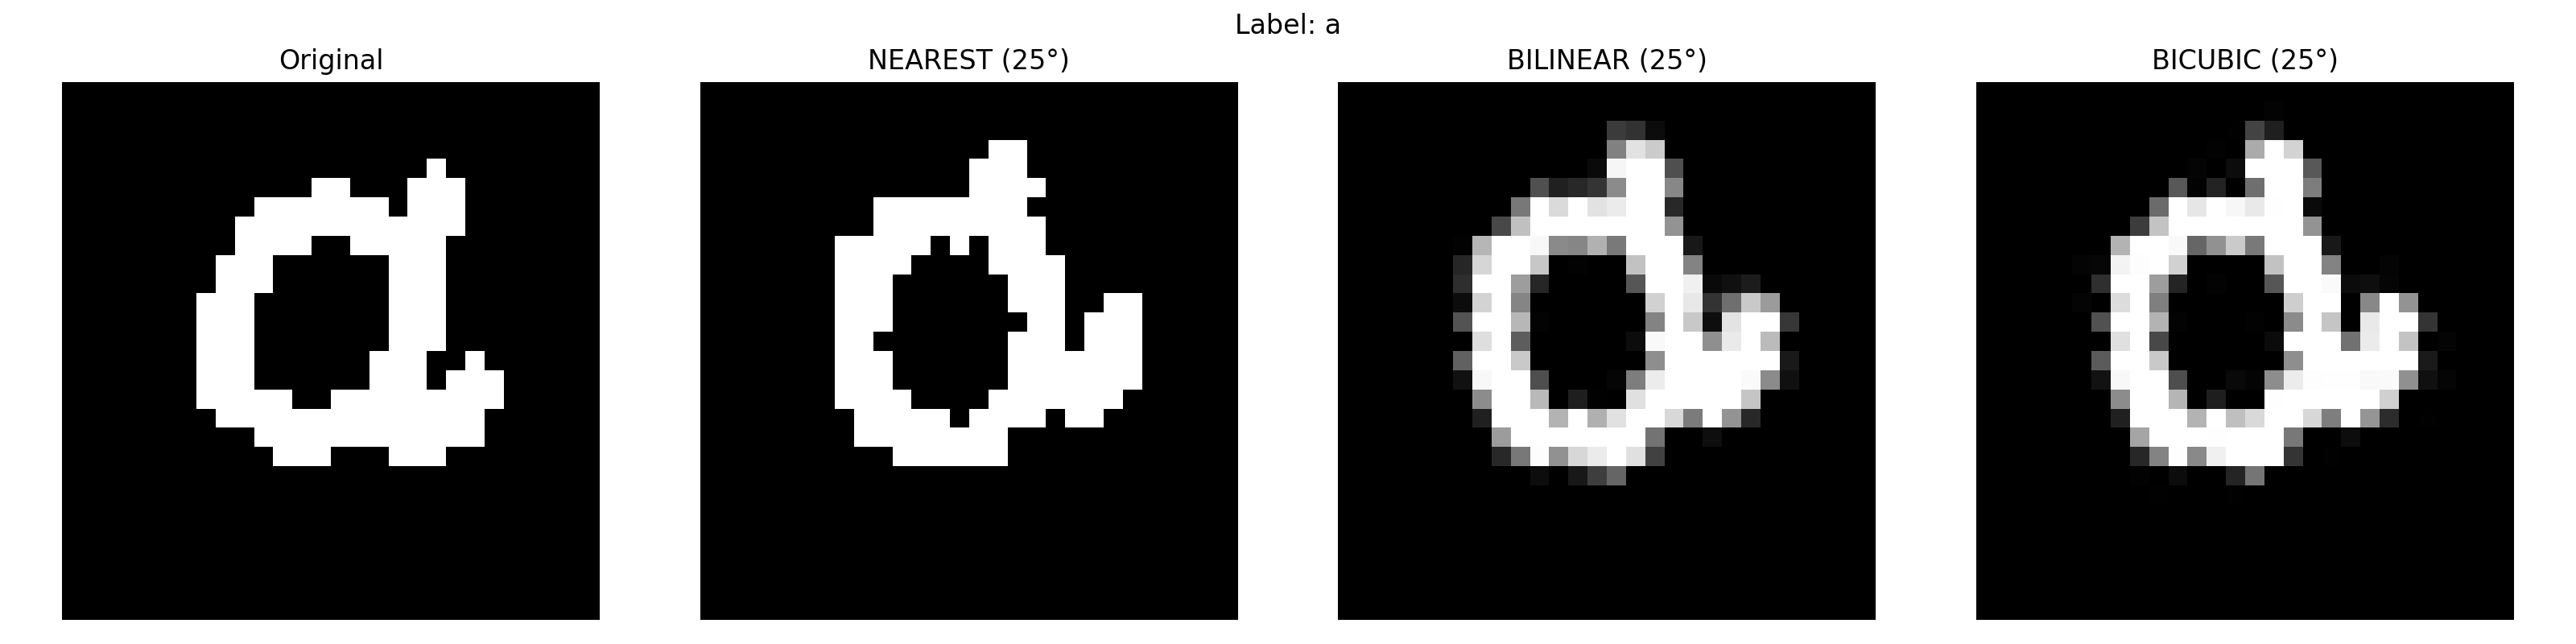

In [6]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['а'])
plot_rotated_with_interpolations(img, label, angle=25)

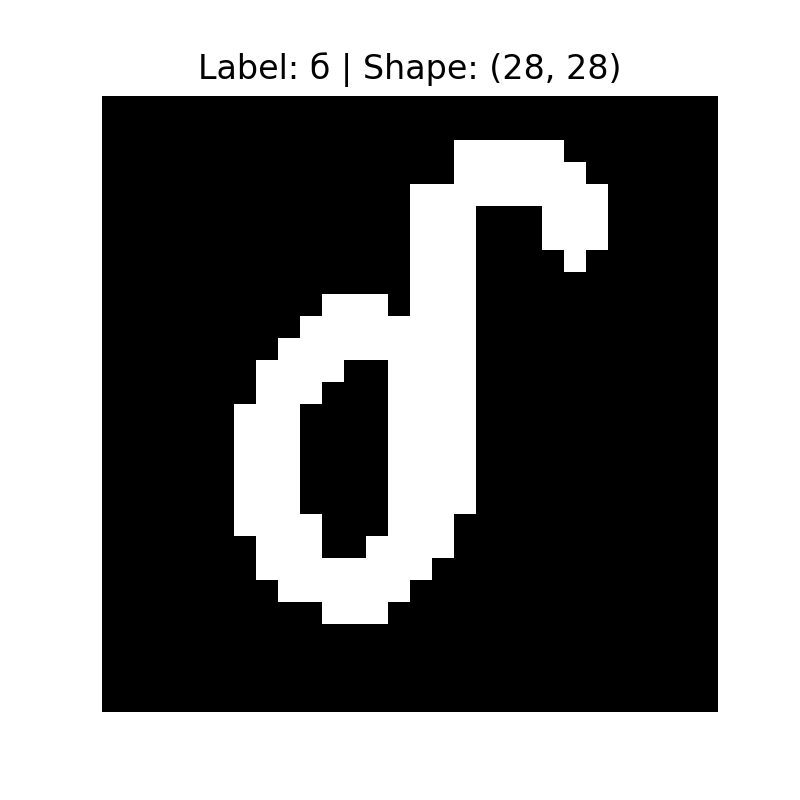

In [7]:
img = generator.generate_б()
label = 'б'
plot_single_image(img, label)

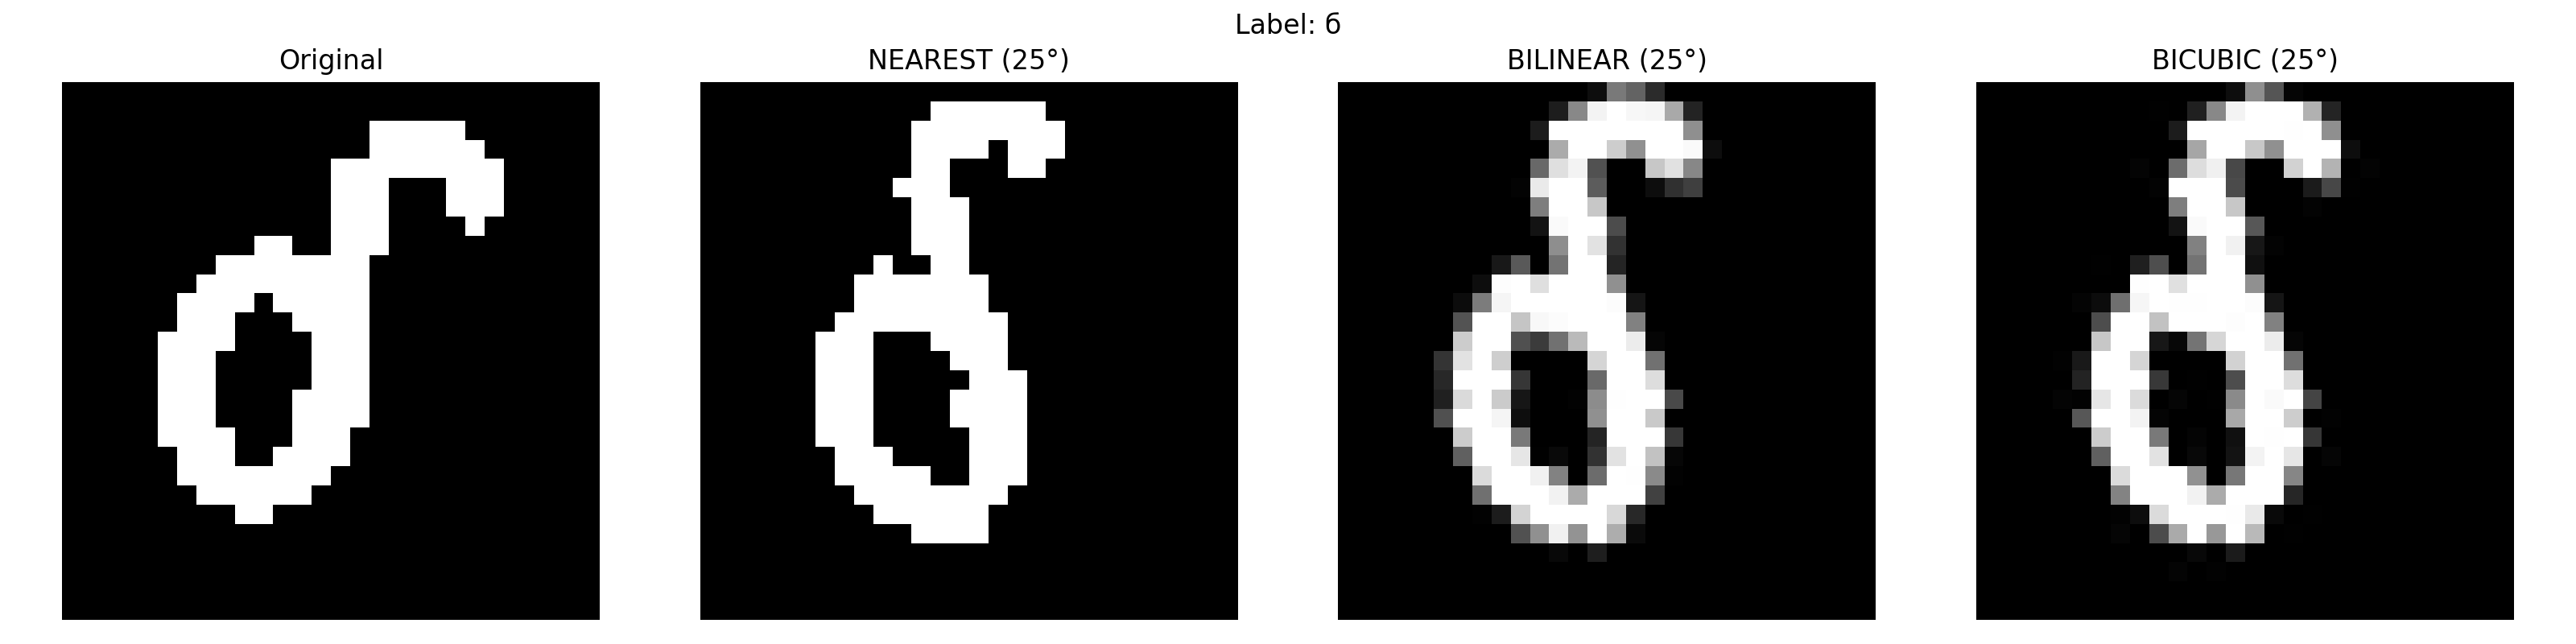

In [8]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['б'])
plot_rotated_with_interpolations(img, label, angle=25)

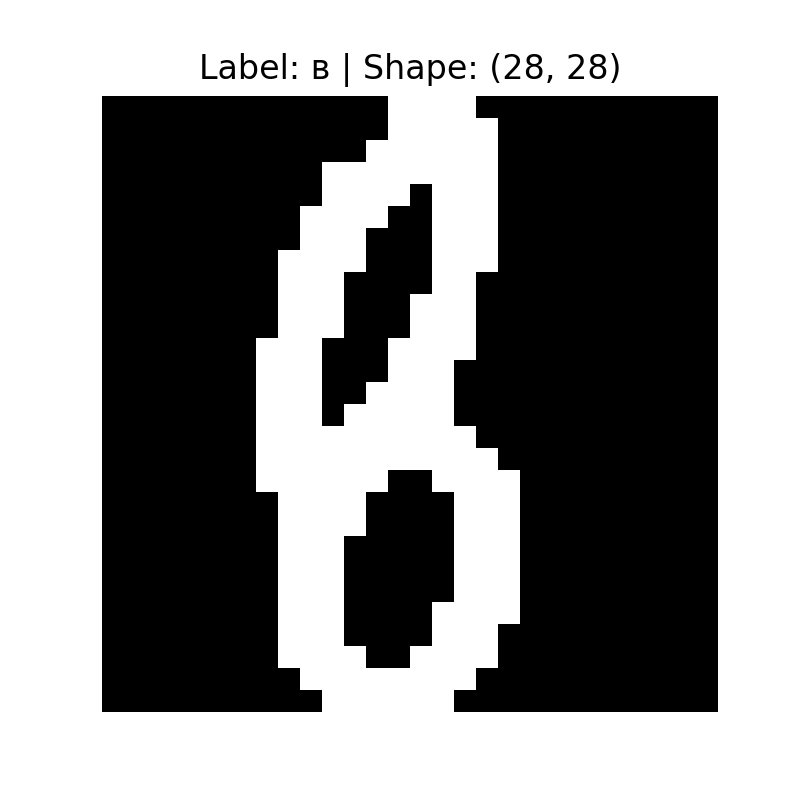

In [9]:
img = generator.generate_в()
label = 'в'
plot_single_image(img, label)

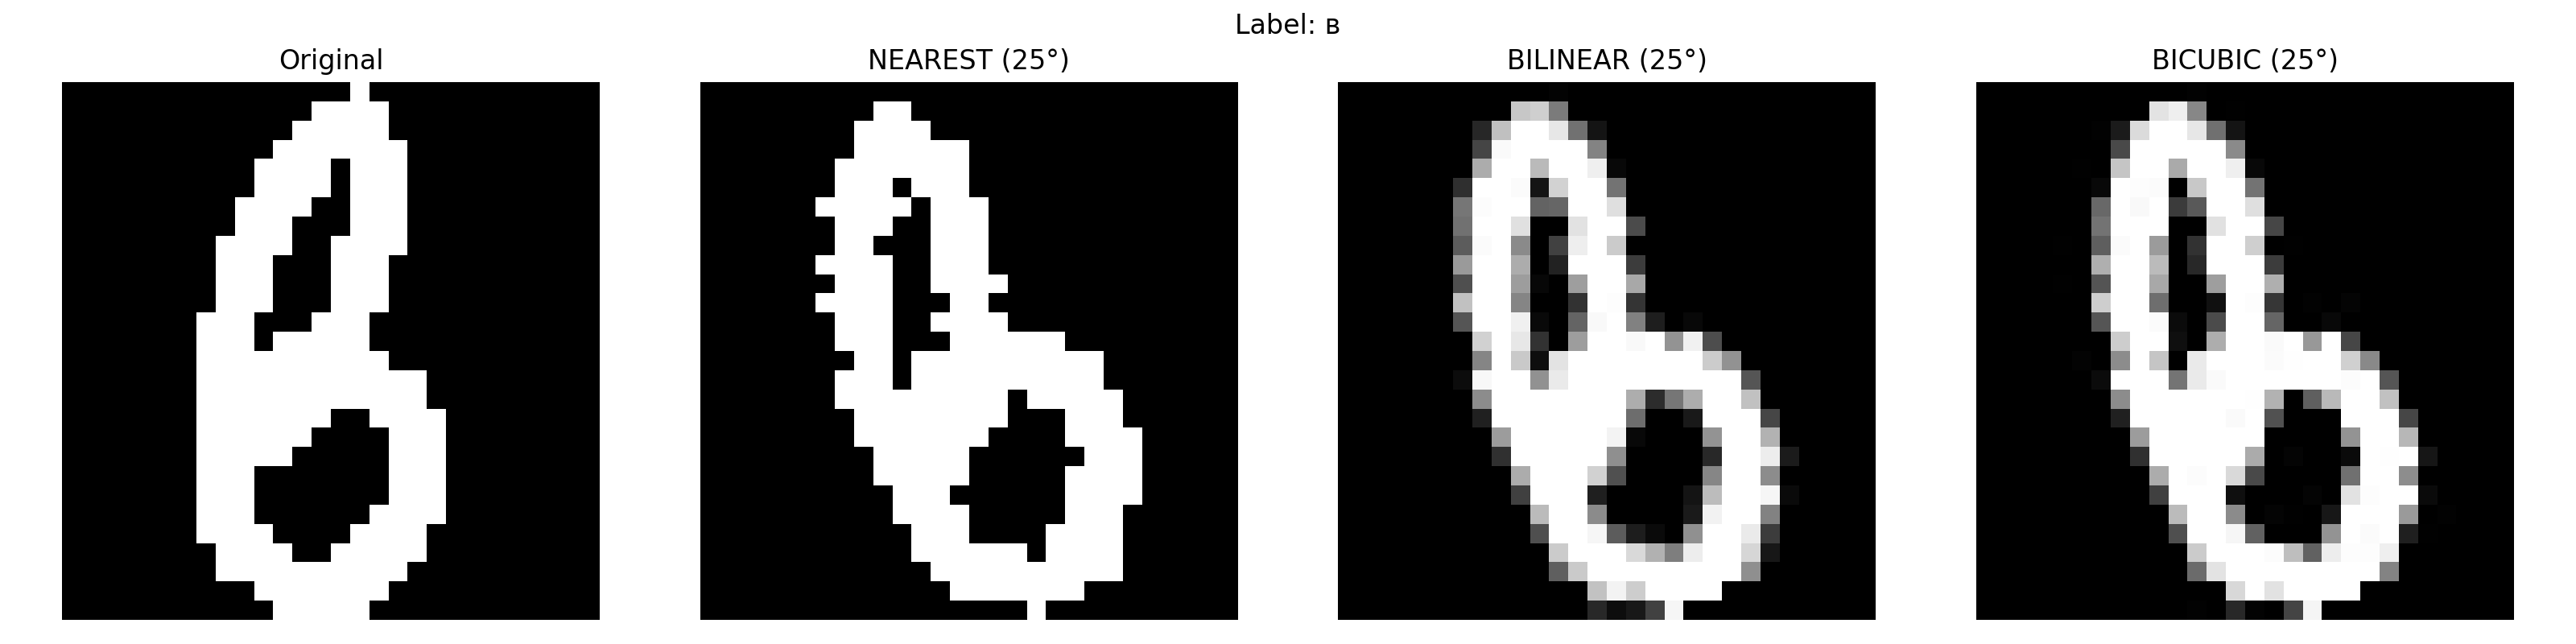

In [10]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['в'])
plot_rotated_with_interpolations(img, label, angle=25)

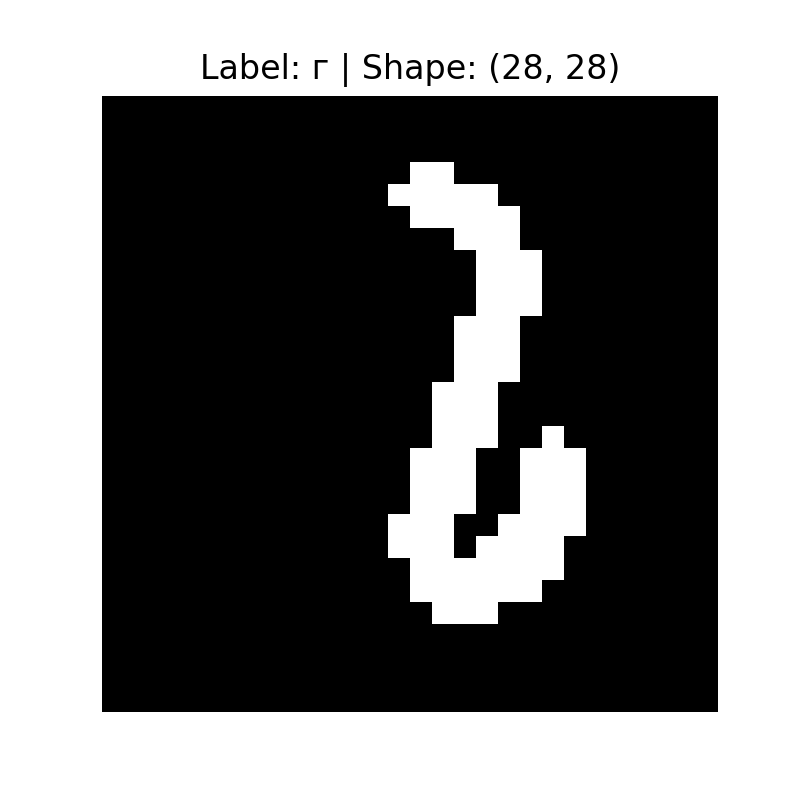

In [11]:
# Генерация изображений
img = generator.generate_г()
label = 'г'
plot_single_image(img, label)

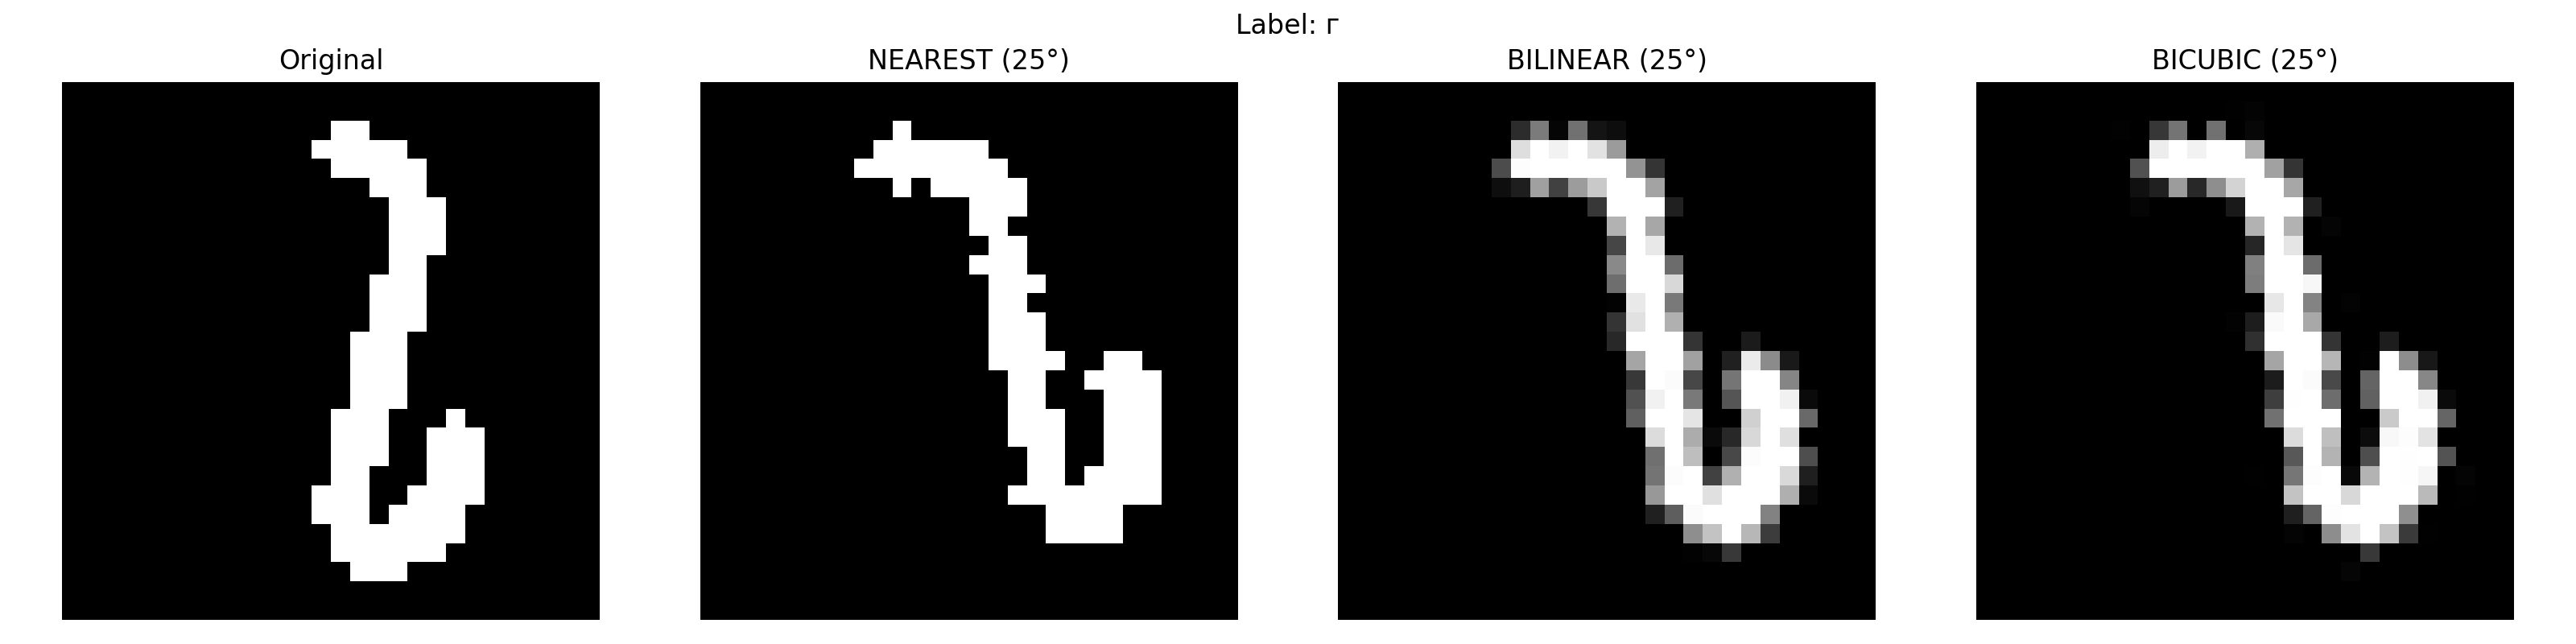

In [12]:
generator = LowerCaseLettersGenerator(seed=42)
img, label = generator.generate(include=['г'])
plot_rotated_with_interpolations(img, label, angle=25)